# Part 2. Problem overview

Notebook này dùng dữ liệu chính thức để tái dựng chart mở bài của Part 2. Mục tiêu là chứng minh chất lượng cầu suy giảm mạnh sau năm 2019 dù traffic vẫn tăng.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import Image, display, Markdown

ROOT = Path('/home/lducc/code/datathon')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'notebooks' / 'part2_eda') not in sys.path:
    sys.path.insert(0, str(ROOT / 'notebooks' / 'part2_eda'))

from models.data import load_dataframes, build_daily_frame, build_monthly_inventory_frame, build_segment_inventory_frame
from story_card_helpers import (
    setup_story_theme,
    create_story_card,
    apply_story_header,
    fill_footer,
    save_story_card,
    BLUE,
    ORANGE,
    RED,
    GREEN,
    GRAY,
)

setup_story_theme()
pd.options.display.float_format = lambda value: f"{value:,.2f}"
data = load_dataframes()
daily = build_daily_frame(data)
out_dir = ROOT / 'figures' / 'problem_overview'
out_dir.mkdir(parents=True, exist_ok=True)

monthly = (
    daily.set_index('date')
    .resample('MS')
    .agg(
        sessions=('sessions', 'sum'),
        orders=('orders', 'sum'),
        revenue=('Revenue', 'sum'),
        gross_profit=('gross_profit', 'sum'),
    )
    .reset_index()
)
monthly['conversion'] = monthly['orders'] / monthly['sessions']
monthly['period'] = np.where(monthly['date'].dt.year <= 2018, '2013-2018', '2019-2022')

baseline = monthly.loc[monthly['date'].dt.year.between(2013, 2018), ['sessions', 'orders', 'conversion']].mean()
for metric in ['sessions', 'orders', 'conversion']:
    monthly[f'{metric}_index'] = monthly[metric] / baseline[metric] * 100

summary = (
    monthly.groupby('period')
    .agg(
        monthly_sessions=('sessions', 'mean'),
        monthly_orders=('orders', 'mean'),
        conversion_pct=('conversion', lambda values: values.mean() * 100),
        monthly_revenue=('revenue', 'mean'),
    )
)
display(summary)

,monthly_sessions,monthly_orders,conversion_pct,monthly_revenue
period,,,,
2013-2018,"625,845.18","6,409.41",inf,"154,184,286.33"
2019-2022,"888,262.77","3,062.73",0.35,"91,752,130.24"


## Hình 1

Dưới đây là chart chỉ số hóa sessions, orders và conversion. Phần bóng xám đánh dấu giai đoạn 2018 H2 để làm rõ thời điểm stress tích tụ trước khi cú rơi 2019 thể hiện rõ trên top-line.

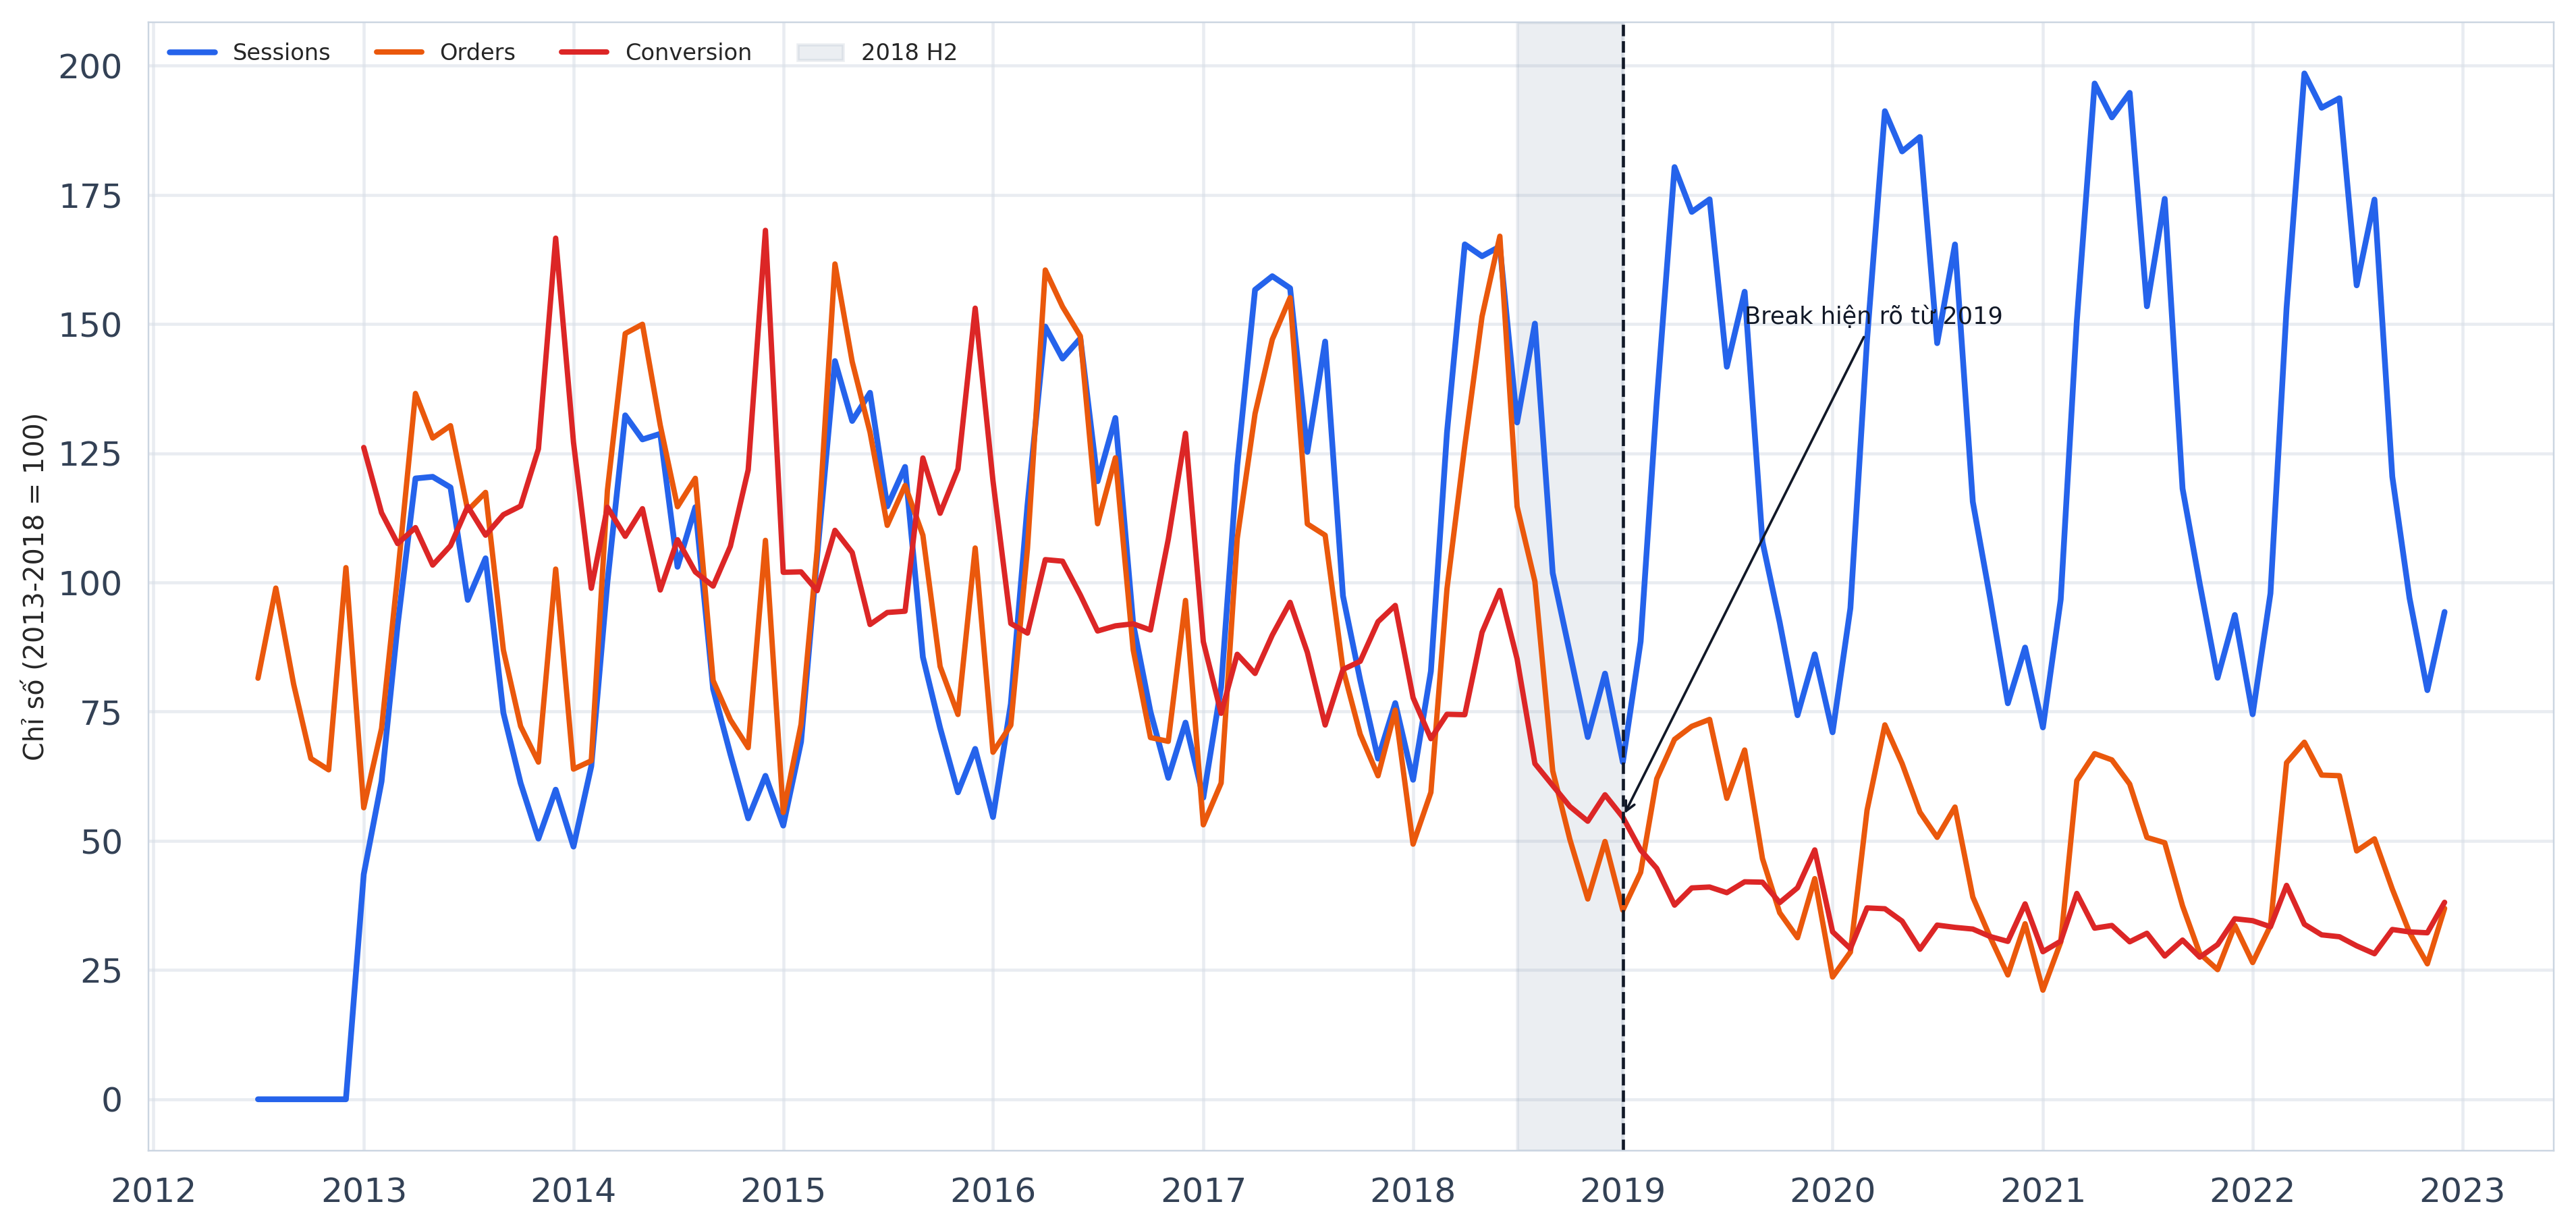

In [2]:
pre = summary.loc['2013-2018']
post = summary.loc['2019-2022']

fig, chart_axes, footer_axes = create_story_card(top_shape=(1, 1), figsize=(18, 10))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Hình 1. Chất lượng cầu suy giảm mạnh sau năm 2019 dù lưu lượng truy cập tiếp tục tăng',
    subtitle='Một chart chỉ số hóa cho thấy doanh nghiệp không thiếu demand; điểm gãy nằm ở khả năng chuyển traffic thành đơn hàng có lãi.',
    encoding_line='Diễn biến đồng thời của sessions, orders và conversion (2013-2022)',
)

ax.plot(monthly['date'], monthly['sessions_index'], color=BLUE, linewidth=2.8, label='Sessions')
ax.plot(monthly['date'], monthly['orders_index'], color=ORANGE, linewidth=2.6, label='Orders')
ax.plot(monthly['date'], monthly['conversion_index'], color=RED, linewidth=2.6, label='Conversion')
ax.axvspan(pd.Timestamp('2018-07-01'), pd.Timestamp('2018-12-31'), color=GRAY, alpha=0.18, label='2018 H2')
ax.axvline(pd.Timestamp('2019-01-01'), color='#111827', linestyle='--', linewidth=1.5)
jan_2019 = monthly.loc[monthly['date'] == pd.Timestamp('2019-01-01'), 'conversion_index'].iloc[0]
ax.annotate(
    'Break hiện rõ từ 2019',
    xy=(pd.Timestamp('2019-01-01'), jan_2019),
    xytext=(pd.Timestamp('2019-08-01'), 150),
    arrowprops={'arrowstyle': '->', 'color': '#111827', 'linewidth': 1.2},
    fontsize=11.5,
    color='#111827',
)
ax.set_ylabel('Chỉ số (2013-2018 = 100)')
ax.set_xlabel('')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', ncol=4, frameon=False)

sessions_change = (post['monthly_sessions'] / pre['monthly_sessions'] - 1) * 100
orders_change = (post['monthly_orders'] / pre['monthly_orders'] - 1) * 100
conversion_change = (post['conversion_pct'] / pre['conversion_pct'] - 1) * 100

fill_footer(
    footer_axes,
    [
        ('Ý tưởng phân tích', 'Chỉ số hóa đồng thời sessions, orders và conversion để tách bài toán traffic khỏi bài toán commercial conversion.'),
        ('Phát hiện chính', f'So với 2013-2018, sessions bình quân tháng tăng {sessions_change:.1f}%, nhưng orders giảm {abs(orders_change):.1f}% và conversion giảm {abs(conversion_change):.1f}%.'),
        ('Hàm ý kinh doanh', 'Doanh nghiệp không thiếu lưu lượng truy cập. Vấn đề nằm ở chất lượng demand và khả năng chuyển traffic thành đơn hàng có lãi sau 2019.'),
    ],
)

out_path = out_dir / '01_demand_quality_break.png'
save_story_card(fig, out_path)
display(Image(filename=str(out_path), width=1500))

### Ý tưởng phân tích
Chỉ số hóa đồng thời sessions, orders và conversion để tách câu hỏi `thiếu traffic` khỏi câu hỏi `traffic vào nhưng không chuyển thành đơn hàng`.

### Phát hiện chính
- Sessions bình quân tháng giai đoạn 2019-2022 cao hơn giai đoạn 2013-2018.
- Orders và conversion cùng giảm mạnh sau 2019, tạo ra một break rõ trên chất lượng cầu.
- Vùng chuyển tiếp từ 2018 H2 sang 2019 là thời điểm hệ thống bắt đầu mất khả năng chuyển traffic thành đơn hàng có lãi.

### Hàm ý kinh doanh
Bài toán không nằm ở việc kéo thêm traffic bằng mọi giá. Trọng tâm phải chuyển sang chất lượng thương mại: assortments, availability, pricing và conversion efficiency.
